# Notebook 05 — Visual Feature Extraction

**Duration:** ~25 minutes

In notebooks 03 and 04 you extracted information and generated themes from legislative text. In this notebook you apply the **exact same pipeline** to images.

The dataset is a curated selection of **World War I recruitment and propaganda posters** from **Archives New Zealand**, accessed via Wikimedia Commons. All images are in the public domain under New Zealand's NZGOAL framework.

You will:

1. Send an image to a vision-capable LLM and extract structured features as JSON
2. Validate the image keywords against parliamentary committee domains using Jaccard similarity — the same method you used on text in notebook 04
3. Compare the model's output against archival metadata written by human archivists

The point: the data type changed. The methodology did not.

## Setup

Run this cell first. If you stored your Groq API key in Colab Secrets (notebook 01), it will load automatically.

Note: this notebook uses a **vision model** — a model that can read images as well as text. The vision model is different from the text model you used in earlier notebooks.

In [ ]:
# ============================================================
# SETUP CELL — Run this once at the start of every notebook
# ============================================================

!pip install groq requests lxml Pillow
import os, json, base64, requests, io
from groq import Groq
from lxml import etree
from PIL import Image
from IPython.display import Image as IPImage, display

# Load API key from Colab Secrets (set up in notebook 01)
try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("API key loaded from Colab Secrets.")
except Exception:
    os.environ["GROQ_API_KEY"] = "paste_your_key_here"   # <-- fallback: paste key here
    print("Could not load from Secrets. Paste your key in the line above.")

client = Groq(api_key=os.environ["GROQ_API_KEY"])
TEXT_MODEL = "llama-3.3-70b-versatile"
VISION_MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

print("Setup complete.")

## Browse the image corpus

We fetch images from the **Wikimedia Commons API** — a public repository of freely licensed media. Archives New Zealand has contributed thousands of historical images to the collection.

The curated corpus for this workshop contains four WWI-era posters — recruitment appeals, propaganda, and government notices. Each one contains visible text, political messaging, and visual symbols designed to persuade. Run the cell below to see all four. Then you will pick your favourite to analyse.

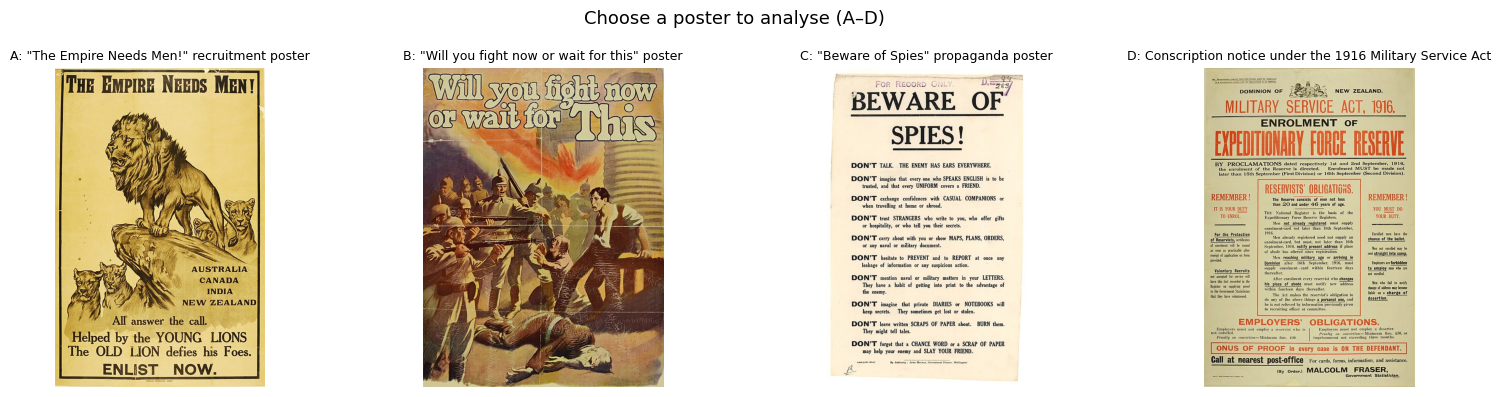

In [20]:
# Curated image corpus — four WWI posters from Archives New Zealand
IMAGE_CORPUS = {
    "A": {
        "title": "File:\"The Empire Needs Men!\" Recruitment poster for World War I (14842191503).jpg",
        "label": "\"The Empire Needs Men!\" recruitment poster",
    },
    "B": {
        "title": "File:\"Will you fight now or wait for this\" recruitment poster (14831036372).jpg",
        "label": "\"Will you fight now or wait for this\" poster",
    },
    "C": {
        "title": "File:'Beware of Spies' World War I propaganda poster (14603583360).jpg",
        "label": "\"Beware of Spies\" propaganda poster",
    },
    "D": {
        "title": "File:Conscription Poster (14644744689).jpg",
        "label": "Conscription notice under the 1916 Military Service Act",
    },
}

api_url = "https://commons.wikimedia.org/w/api.php"
headers = {
    "User-Agent": "UoA-eResearch-LLM-Workshop/1.0 (researchdata@auckland.ac.nz)"
}

# Fetch thumbnails for all four images and display them as a gallery
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (key, info) in zip(axes, IMAGE_CORPUS.items()):
    params = {
        "action": "query",
        "titles": info["title"],
        "prop": "imageinfo",
        "iiprop": "url|size|extmetadata",
        "iiurlwidth": 400,
        "format": "json"
    }
    resp = requests.get(api_url, params=params, headers=headers, timeout=15)
    pages = resp.json()["query"]["pages"]
    page = list(pages.values())[0]
    img_info = page["imageinfo"][0]
    thumb = img_info.get("thumburl", img_info["url"])

    img_resp = requests.get(thumb, headers=headers, timeout=15)
    img = Image.open(io.BytesIO(img_resp.content))

    ax.imshow(img)
    ax.set_title(f"{key}: {info['label']}", fontsize=9, wrap=True)
    ax.axis("off")

plt.suptitle("Choose a poster to analyse (A–D)", fontsize=13)
plt.tight_layout()
plt.show()

You chose A: "The Empire Needs Men!" recruitment poster
Image size: 400x608 — ready for API.



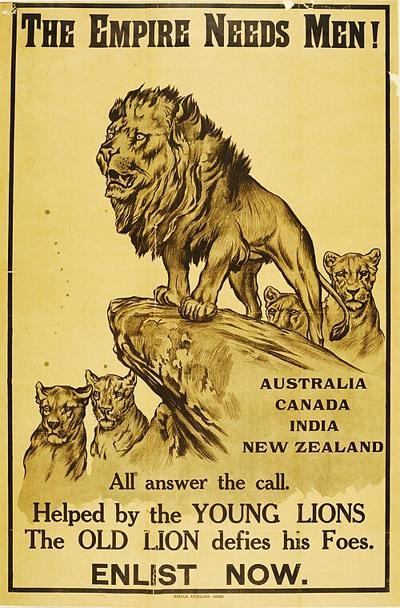

In [21]:
# ============================================================
# CHOOSE YOUR IMAGE — change the letter to A, B, C, or D
# ============================================================
CHOSEN = "A"

# Fetch the chosen image
chosen_info = IMAGE_CORPUS[CHOSEN]
image_title = chosen_info["title"]

params = {
    "action": "query",
    "titles": image_title,
    "prop": "imageinfo",
    "iiprop": "url|size|extmetadata",
    "iiurlwidth": 400,
    "format": "json"
}
api_response = requests.get(api_url, params=params, headers=headers, timeout=15)
pages = api_response.json()["query"]["pages"]
page = list(pages.values())[0]
image_info = page["imageinfo"][0]
thumb_url = image_info.get("thumburl", image_info["url"])

# Extract the archival description (used later for validation)
metadata = image_info.get("extmetadata", {})
archival_description = metadata.get("ImageDescription", {}).get("value", "No description available.")

# Download and prepare the image
img_response = requests.get(thumb_url, headers=headers, timeout=15)
img = Image.open(io.BytesIO(img_response.content))

new_width = 400
if img.width != new_width:
    ratio = new_width / img.width
    new_height = int(img.height * ratio)
    img = img.resize((new_width, new_height))
else:
    new_height = img.height

# Convert to base64 for the API call
buffer = io.BytesIO()
img.save(buffer, format="JPEG")
img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# Display the chosen image
print(f"You chose {CHOSEN}: {chosen_info['label']}")
print(f"Image size: {new_width}x{new_height} — ready for API.")
print()
display(IPImage(data=buffer.getvalue(), format="jpeg"))


You should see your chosen image displayed above. Take a moment to look at it before we ask the model to analyse it.

What do you notice? What details stand out? What do you think the image is about? Hold those observations — you will compare them against what the model produces.


## Where this fits in the research workflow

> **Research context:** The published study on NZ legislative networks (Ardekani et al., 2026) worked entirely with text. But the extraction and validation logic you have been practising works on any unstructured source. Images are just another kind of unstructured data. The pipeline is identical: extract structured features, generate keywords, validate against an external reference.

In this notebook you are doing:
- **Extraction** (Step 2) — pulling structured JSON from an image instead of from XML
- **Interpretation** (Step 6) — validating image keywords against committee domains using Jaccard similarity

## Exercise a — Structured JSON extraction from an image

In notebook 03 you asked the LLM to extract Act references from text as JSON. Now you do the same thing with an image — ask the model to describe what it sees and return the results in a structured format.

The prompt asks the model to fill in these fields:
- **scene_description** — what is happening in the image
- **political_claim** — what political argument or demand is being made
- **visible_text** — any text that appears in the image
- **symbols** — visual symbols, logos, flags, or iconography
- **keywords** — 20 to 25 keywords describing the image's content (this feeds into exercise b)
- **confidence** — how confident the model is in its analysis (high / medium / low)

Run the cell below.

In [ ]:
vision_response = client.chat.completions.create(
    model=VISION_MODEL,
    temperature=0,
    messages=[
        {
            "role": "system",
            "content": "You are a research assistant analysing historical archival images from New Zealand."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """Analyse this historical image from Archives New Zealand.

Extract the following features and return them as a JSON object:
{
  "scene_description": "What is happening in this image?",
  "political_claim": "What political argument or demand is being made?",
  "visible_text": "Any text visible in the image (or 'none' if not legible)",
  "symbols": "Visual symbols, logos, flags, or iconography present",
  "keywords": ["20 - 25 keywords describing the content"],
  "confidence": "high, medium, or low"
}

Return ONLY the JSON object."""
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{img_base64}"
                    }
                }
            ]
        }
    ]
)

vision_raw = vision_response.choices[0].message.content.strip()

# Parse the JSON
try:
    image_features = json.loads(vision_raw)
except json.JSONDecodeError:
    # Strip markdown code fences if present
    cleaned = vision_raw.strip("`").strip()
    if cleaned.startswith("json"):
        cleaned = cleaned[4:].strip()
    image_features = json.loads(cleaned)

# Pretty-print the results
print("Extracted features:")
print("=" * 60)
for key, value in image_features.items():
    if isinstance(value, list):
        print(f"\n{key}:")
        for item in value:
            print(f"  - {item}")
    else:
        print(f"\n{key}: {value}")

Extracted features:

scene_description: A World War I recruitment poster featuring a lion and its cubs, symbolizing the British Empire and its dominions.

political_claim: The poster urges men to enlist in the military to support the British Empire during World War I, emphasizing the need for men from Australia, Canada, India, and New Zealand.

visible_text: THE EMPIRE NEEDS MEN! AUSTRALIA CANADA INDIA NEW ZEALAND All answer the call. Helped by the YOUNG LIONS The OLD LION defies his Foes. ENLIST NOW.

symbols:
  - Lion and lion cubs (symbols of the British Empire), text mentioning dominion countries

keywords:
  - World War I
  - recruitment poster
  - British Empire
  - Australia
  - Canada
  - India
  - New Zealand
  - lion
  - enlistment
  - military service

confidence: high


Read through the results. Some questions to consider:

- Does the **scene description** match what you see?
- Did the model correctly read any **visible text** in the image, or did it guess?
- Is the **political claim** reasonable, or did the model project something that is not there?
- How would you rate your own confidence compared to the model's?

This is the same critical eye you applied to text extraction in notebook 03. The data type is different. The questions are the same.

## Exercise b — Cross-modal Jaccard validation

In notebook 04 you compared theme keywords against parliamentary committee keyword sets using Jaccard similarity. Now you do the same thing with the keywords the model extracted from the image.

The question: does the model's keyword description of a historical protest image align with any recognisable policy domain?

In [32]:
# Jaccard similarity function (same as notebook 04)
def jaccard_similarity(set_a, set_b):
    """Calculate Jaccard similarity between two sets of strings."""
    a = set(w.lower() for w in set_a)
    b = set(w.lower() for w in set_b)
    intersection = a & b
    union = a | b
    if not union:
        return 0.0
    return len(intersection) / len(union)

# Parliamentary select committee keyword sets
# Same as notebook 04, plus the Foreign Affairs, Defence and Trade Committee
# which is relevant to the wartime image corpus in this notebook.
COMMITTEE_KEYWORDS = {
    "Justice Committee": [
        "criminal", "justice", "court", "offence", "penalty",
        "prosecution", "enforcement", "police", "imprisonment",
        "tribunal", "legal", "rights", "appeal", "sentence", "conviction"
    ],
    "Finance and Expenditure Committee": [
        "financial", "revenue", "tax", "expenditure", "budget",
        "fiscal", "economic", "payment", "fund", "investment",
        "commercial", "income", "cost", "penalty", "levy"
    ],
    "Governance and Administration Committee": [
        "privacy", "information", "data", "personal", "agency",
        "public", "government", "official", "disclosure", "access",
        "transparency", "accountability", "complaint", "commissioner",
        "record"
    ],
    "Social Services and Community Committee": [
        "social", "community", "welfare", "family", "housing",
        "poverty", "employment", "education", "youth", "elderly",
        "disability", "support", "benefit", "vulnerable", "protection"
    ],
    "Foreign Affairs, Defence and Trade Committee": [
        "defence", "military", "war", "foreign", "security",
        "armed", "treaty", "trade", "intelligence", "espionage",
        "diplomacy", "veteran", "conscription", "alliance", "sovereignty"
    ]
}

print("Jaccard function and committee keywords loaded.")

Jaccard function and committee keywords loaded.


In [33]:
# Get the image keywords from the extraction
image_keywords = image_features.get("keywords", [])

print(f"Image keywords ({len(image_keywords)}):")
print(f"  {', '.join(image_keywords)}")
print()

# Compare image keywords against each committee
print("Image keywords — Jaccard similarity with each committee:")
print("=" * 60)
image_scores = {}
for committee, kws in COMMITTEE_KEYWORDS.items():
    score = jaccard_similarity(image_keywords, kws)
    image_scores[committee] = score
    bar = "█" * int(score * 40)
    print(f"  {committee:45s} {score:.3f} {bar}")

best_committee = max(image_scores, key=image_scores.get)
print(f"\nBest match: {best_committee} ({image_scores[best_committee]:.3f})")

Image keywords (12):
  World War I, recruitment poster, British Empire, lion, cubs, Australia, Canada, India, New Zealand, enlistment, military, propaganda

Image keywords — Jaccard similarity with each committee:
  Justice Committee                             0.000 
  Finance and Expenditure Committee             0.000 
  Governance and Administration Committee       0.000 
  Social Services and Community Committee       0.000 
  Foreign Affairs, Defence and Trade Committee  0.038 █

Best match: Foreign Affairs, Defence and Trade Committee (0.038)


### Does the match make sense?

Think about the poster you chose and which committee scored highest:
- **"The Empire Needs Men!"** (A) is a recruitment appeal using imperial imagery — expect Justice or Governance
- **"Will you fight now or wait for this"** (B) uses fear and threat — expect Justice (enforcement, penalty) or Social Services
- **"Beware of Spies"** (C) is about surveillance and vigilance — expect Governance and Administration (information, disclosure, transparency)
- **Conscription notice** (D) is a legal notice under the Military Service Act — expect Justice (legal, enforcement, prosecution)

Think about:
- Does the model's best-match committee align with what you see in the poster?
- If there is a discrepancy, is it because the model misread the image, or because the committee keywords do not capture wartime topics well?
- Would a human researcher categorise this poster the same way?

### Compare against archival metadata

The Wikimedia Commons API provides the original archival description for each image. This is metadata written by human archivists at Archives New Zealand — an independent reference we can compare against.

This is the same logic as the human spot-check from notebook 03: compare what the model produced against a trusted external source.

In [34]:
# Show the archival metadata alongside the model's description
print("ARCHIVAL METADATA (written by human archivists):")
print("=" * 60)
print(archival_description)
print()
print("MODEL'S DESCRIPTION:")
print("=" * 60)
print(image_features.get("scene_description", "(not available)"))
print()
print("MODEL'S POLITICAL CLAIM:")
print("=" * 60)
print(image_features.get("political_claim", "(not available)"))
print()
print("Questions to consider:")
print("  1. Does the model's description match the archival record?")
print("  2. Did the model add details not in the metadata (hallucination)?")
print("  3. Did the metadata contain information the model missed?")

ARCHIVAL METADATA (written by human archivists):
<p>New Zealand Expeditionary Force recruitment poster from Archives New Zealand's Army Department files.
</p>
Archives New Zealand Reference: AD1 9/169/2/1 R22444228

MODEL'S DESCRIPTION:
A World War I recruitment poster featuring a large lion standing on a rock with three cubs, symbolizing the British Empire and its dominions.

MODEL'S POLITICAL CLAIM:
The poster is making a political demand for men to enlist in the military to support the British Empire during World War I.

Questions to consider:
  1. Does the model's description match the archival record?
  2. Did the model add details not in the metadata (hallucination)?
  3. Did the metadata contain information the model missed?


> "You used the same extraction and validation pipeline on an image that you used on text. The data type changed. The methodology did not."

## Optional: Try a different poster

Go back to the image selection cell and change `CHOSEN` to a different letter (A–D). Run all the cells again from that point and see how the results differ.

You can also try these take-home exercises after the workshop:
- Run the extraction with a **positioned persona** (e.g. "You are a military historian" or "You are a pacifist activist") and compare the Jaccard scores
- Use **adversarial prompting** — challenge the model's scene description and ask it to reconsider
- Try an image from a completely different domain and see which committee it aligns with

## What you accomplished

In this notebook you:

- Fetched a historical image from Archives New Zealand via the Wikimedia Commons API
- Extracted structured features (scene, political claim, text, symbols, keywords) from the image using a vision-capable LLM
- Validated the image keywords against parliamentary committee domains using **Jaccard similarity** — the same method you used on text in notebook 04
- Compared the model's output against archival metadata written by human archivists — a **human spot-check** across data types

You now have four validation techniques in your toolkit:

| Technique | What it checks | When you used it |
|-----------|---------------|------------------|
| **Consistency check** | Does the method give the same answer twice? | Notebook 02 (temperature) |
| **Cross-method comparison** | Do two methods agree? | Notebook 03 (regex vs LLM) |
| **Jaccard validation** | Do the results align with a known reference? | Notebooks 04 and 05 |
| **Human spot-check** | Does the output match a trusted external source? | Notebooks 03 and 05 |

The key insight: the pipeline you learned in this workshop — extract, compare, validate — works on any unstructured data, not just text. The tools are the same. The questions you ask about trust, precision, and framing are the same.

**Next up:** The instructor will wrap up with a summary of what you did today and where to go next.